# skyflat

> Investigate and remove an atemporal background from a set of observations.


In [ ]:
# | default_exp euclid.skyflat

In this notebook, we determine an atemporal (i.e. constant, or at least slowly-varying) background to subtract from the observations. We sometimes refer to this as a "skyflat", since its purpose is to flatten the sky. However, we subtract the resulting model from the data, so it is not a flat-field correction.

::: {.callout-warning}
This notebook takes 2-3 hours to create a skyflat from all of the Q1 data.
:::

In [ ]:
# | export

import warnings

import numpy as np
import xarray as xr
import astropy.io.fits as fits
from scipy.interpolate import interpn

from nicl.euclid.xarray import (
    read_all_zarr_refs,
    write_da_to_fits,
    xr_fast_mask,
)

In [ ]:
# | hide
# Additional imports used in the examples

import matplotlib.pyplot as plt
from nicl.euclid.utilities import default_data_path
from nicl.euclid.xarray import (
    create_all_zarr_refs,
)

To speed up the creation of the skyflats, we coarsen the data by taking the median in boxes. As this coarse data is used repeatedly, we compute it once for each observation and store it on disk.


In [ ]:
# | export


def create_coarse_data(obs_id, zarr_path, n_pix=51, verbose=False):
    """Create and store the coarse data for a given observation ID.

    Coarse data is computed by taking the median in boxes of size `n_pix` x `n_pix`.
    """
    coarse_path = zarr_path / f"{obs_id}/coarse_{n_pix}.zarr"
    if not coarse_path.exists():
        ds, _, _ = read_all_zarr_refs(zarr_path, obs_id)
        data = ds["SCI"]
        mask = xr_fast_mask(data, estimate_background=True, verbose=verbose)
        if "DQ" in ds.data_vars:
            mask |= ds["DQ"] & 1 > 0
        elif "FLG" in ds.data_vars:
            mask |= ds["FLG"] & 1 > 0
        masked_data = data.where(~mask)
        with warnings.catch_warnings():
            warnings.filterwarnings("ignore", r"All-NaN (slice|axis) encountered")
            coarse_data = masked_data.coarsen(dict(x=n_pix, y=n_pix), boundary="pad").median()
            coarse_data.to_zarr(coarse_path)

To capture potential slow temporal variations in the skyflat, we group the observations into a window around each observation. We then compute the skyflat for each observation using the observations in the group.

In [ ]:
# | export


def group_obs_ids(
    target_obs_ids,  # list of observation IDs for which to create groups
    available_obs_ids,  # list of observation IDs available for grouping 
    half_window=3,  # half-window size for grouping
    max_gap_size=2,  # maximum gap size for judging whether a sequence is continuous
) -> dict[int, list[int]]:  # dict of grouped observation IDs for each observation ID
    """Group the observation IDs around each observation ID.

    Determines the best group of observations for characterising the skyflat for a given observation ID.
    For observations within a continuous sequence, the group comprises the `half_window` observations on
    either side of the given observation ID. The target observation itself is not included in the group.
    The group is restricted to observations in a continuous sequence (with gaps no larger than `max_gap_size`),
    such that it may be truncated for observations close to the edge of a sequence. Where possible, the number
    of observations on the opposing side is increased, to maintain a total group size of `2 * half_window`.
    However, for short sequences, the group may be smaller.
    """
    available_obs_ids = sorted(available_obs_ids)
    gaps = np.where(np.diff(available_obs_ids) > 1 + max_gap_size)[0]
    group_starts = [0] + list(gaps + 1)
    group_ends = list(gaps) + [len(available_obs_ids)]

    sequential_groups = [
        available_obs_ids[start : end + 1] for start, end in zip(group_starts, group_ends)
    ]

    group_for_obs_id = {}
    for obs_id in target_obs_ids:
        for group in sequential_groups:
            if obs_id in group:
                min_obs_id_group = min(group)
                max_obs_id_group = max(group)
                for hw in range(half_window, 4 * half_window + 1):
                    min_obs_id = max(min_obs_id_group, obs_id - hw)
                    max_obs_id = min(max_obs_id_group, obs_id + hw)
                    selected_obs_ids = [
                        i for i in range(min_obs_id, max_obs_id + 1) if i in available_obs_ids
                    ]
                    if len(selected_obs_ids) == 2 * half_window + 1:
                        break
                    elif len(selected_obs_ids) > 2 * half_window + 1:
                        obs_id_idx = selected_obs_ids.index(obs_id) 
                        if obs_id_idx < half_window:
                            selected_obs_ids = selected_obs_ids[:-1]
                        else:
                            selected_obs_ids = selected_obs_ids[1:]
                        break
                selected_obs_ids.remove(obs_id)
                group_for_obs_id[obs_id] = selected_obs_ids
    return group_for_obs_id

The skyflat is simply the median of the coarse data over each group of observations.

We can also compute the error on the skyflat by taking the median absolute deviation of the coarse data over each group of observations.

In [ ]:
# | export

def normalise_per_dither(data):
    """Additively normalise the data to zero median per dither."""
    agg_dims = ["x", "y", "detector"]
    median_per_dither = data.median(dim=agg_dims, keep_attrs=True)
    data = data - median_per_dither
    return data


def construct_skyflats(obs_id, data, group_for_obs_id):
    """Construct the skyflats for a given `obs_id`."""
    group_obs_ids = group_for_obs_id[obs_id]
    group_data = data.sel(observation_id=data.observation_id.isin(group_obs_ids))
    agg_dims = ["observation_id", "dither"]
    median = group_data.median(dim=agg_dims, keep_attrs=True)
    return median


def construct_skyflats_err(obs_id, data, group_for_obs_id, median):
    """Construct the error on the skyflats for a given `obs_id`."""
    group_obs_ids = group_for_obs_id[obs_id]
    group_data = data.sel(observation_id=data.observation_id.isin(group_obs_ids))
    abs_deviation = abs(group_data - median.sel(observation_id=obs_id))
    agg_dims = ["observation_id", "dither"]
    mad = abs_deviation.median(dim=agg_dims, keep_attrs=True)
    n_ok = np.isfinite(data).sum(dim=agg_dims)
    err = mad * 1.4826 / np.sqrt(n_ok)
    return err

In [ ]:
# | export


def write_skyflats(obs_id, flats, outpath, wcs=None, flats_err=None):
    """Write the skyflats for a given `obs_id` to disk as FITS files."""
    if wcs is not None:
        wcs_out = wcs.isel(dither=0, observation_id=0)
        wcs_out = wcs_out.squeeze(drop=True)
        wcs_out["CRVAL1"] = 0
        wcs_out["CRVAL2"] = 0
    else:
        wcs_out = None
    outpath.mkdir(parents=True, exist_ok=True)
    for filt in flats.filter.values:
        flat = flats.sel(filter=filt)
        flat = flat.compute()
        write_da_to_fits(
            flat,
            outpath / f"flat-{obs_id}-{filt}.fits",
            da_wcs=wcs_out,
            overwrite=True,
        )
    if flats_err is not None:
        for filt in flats_err.filter.values:
            err = flats_err.sel(filter=filt)
            err = err.compute()
            write_da_to_fits(
                err,
                outpath / f"flat-err-{obs_id}-{filt}.fits",
                da_wcs=wcs_out,
                overwrite=True,
            )

In [ ]:
# | export


def read_skyflat(obs_id, filter, detector, skyflat_path):
    skyflat_fn = skyflat_path / f"flat-{obs_id}-{filter}.fits"
    skyflat = fits.getdata(skyflat_fn, extname=detector)
    return skyflat

In [ ]:
# | export


def correct_for_zp(data, zp):
    """Correct the data for the zero-point variations between detectors."""
    zp_shift = 10 ** (-0.4 * zp["ZP"])
    zp_shift /= zp_shift.mean(dim=["observation_id", "dither", "filter"])
    return data * zp_shift

In [ ]:
# | export


def interpolate_skyflats(flat, data):
    """Interpolate the `flat` to the x, y coordinates of the `data`."""
    if isinstance(flat, xr.DataArray) or isinstance(flat, xr.Dataset):
        skyflat = flat.interp(
            x=data.x.values,
            y=data.y.values,
            assume_sorted=True,
            method="nearest",
            kwargs={"fill_value": "extrapolate"},
        )
    else:
        coarse_factor = np.array(data.shape) // np.array(flat.shape)
        pix = [np.arange(s) for s in data.shape]
        coarse_pix = [
            np.mean(p.reshape(-1, coarse_factor[i]), axis=1, dtype=np.float32) for i, p in enumerate(pix)
        ]
        outpix = np.meshgrid(*pix, indexing="ij")
        outpix = np.moveaxis(outpix, 0, -1)
        skyflat = interpn(
            coarse_pix,
            flat,
            outpix,
            method="nearest",
            bounds_error=False,
            fill_value=None,
        )
    return skyflat

In [ ]:
# | export


def create_skyflats(obs_id, group_for_obs_id, zarr_path, zp=None, n_pix=51, normalise=True):
    """Read the coarse data and compute the skyflats for a given `obs_id`."""
    group_obs_ids = group_for_obs_id[obs_id]
    for group_obs_id in group_obs_ids:
        create_coarse_data(group_obs_id, zarr_path, n_pix=n_pix, verbose=verbose)
    coarse_data = xr.open_mfdataset(
        zarr_path.glob(f"*/coarse_{n_pix}.zarr"), engine="zarr", combine="nested", concat_dim="observation_id"
    )
    coarse_data = coarse_data["SCI"]
    if zp is not None:
        coarse_data = correct_for_zp(coarse_data, zp)
    if normalise:
        coarse_data = normalise_per_dither(coarse_data)
    flats = construct_skyflats(obs_id, coarse_data, group_for_obs_id)
    return flats

In [ ]:
# | export


def apply_skyflat(data, skyflat):
    """Apply a coarse `skyflat` to some `data`."""
    skyflat_interp = interpolate_skyflats(skyflat, data)
    return data - skyflat_interp

## Example

In [ ]:
path = default_data_path("Q1_R1", "NIR")
zarr_path = default_data_path("zarr", "Q1_R1", "NIR")
outpath = default_data_path("Q1_R1_processed_test", "skyflat")

First we ensure that zarr references have been created for all of the observations.

In [ ]:
create_all_zarr_refs(path, zarr_path)

We can then read the data and determine the groups of observations to use for computing the skyflats for each observation.

In [ ]:
ds, wcs, zp = read_all_zarr_refs(zarr_path)
obs_ids = sorted(ds.observation_id.values)
group_for_obs_id = group_obs_ids(obs_ids, obs_ids, half_window=3)

We go ahead and compute the skyflats for an example observation.


In [ ]:
n_pix = 51
obs_id = 2683
flats = create_skyflats(obs_id, group_for_obs_id, zarr_path, zp, n_pix=n_pix)

Below we plot one of the skyflats for a single filter and detector.


/home/ppzsb1/anaconda/envs/icl/lib/python3.12/site-packages/numpy/lib/_nanfunctions_impl.py:1217: RuntimeWarning: All-NaN slice encountered
  return fnb._ureduce(a, func=_nanmedian, keepdims=keepdims,
/home/ppzsb1/anaconda/envs/icl/lib/python3.12/site-packages/numpy/lib/_nanfunctions_impl.py:1217: RuntimeWarning: All-NaN slice encountered
  return fnb._ureduce(a, func=_nanmedian, keepdims=keepdims,
/home/ppzsb1/anaconda/envs/icl/lib/python3.12/site-packages/numpy/lib/_nanfunctions_impl.py:1217: RuntimeWarning: All-NaN slice encountered
  return fnb._ureduce(a, func=_nanmedian, keepdims=keepdims,
/home/ppzsb1/anaconda/envs/icl/lib/python3.12/site-packages/numpy/lib/_nanfunctions_impl.py:1217: RuntimeWarning: All-NaN slice encountered
  return fnb._ureduce(a, func=_nanmedian, keepdims=keepdims,
/home/ppzsb1/anaconda/envs/icl/lib/python3.12/site-packages/numpy/lib/_nanfunctions_impl.py:1217: RuntimeWarning: All-NaN slice encountered
  return fnb._ureduce(a, func=_nanmedian, keepdims=keepd

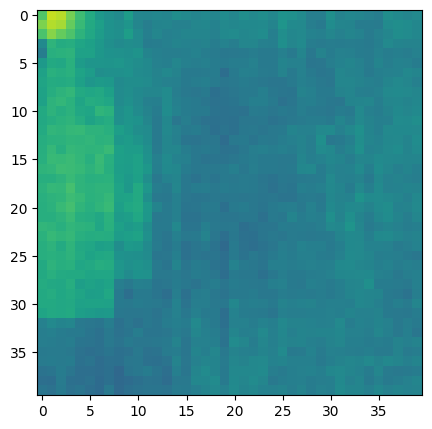

In [ ]:
fig, ax = plt.subplots(figsize=(5, 5))
plt.imshow(
    flats.sel(filter="J", detector="DET11"), vmin=-10, vmax=10, interpolation="none"
);

The skyflats are coarse, so to apply them we need to interpolate them to the coordinates of the data. We use the nearest-neighbour interpolation method, with an appropriate choice of coarsening factor, to maintain the sharp 10x10 pixel structure seen in the skyflats.


In [ ]:
flats_interp = interpolate_skyflats(flats, ds)

In [ ]:
flat_interp = flats_interp.sel(filter="J", detector="DET11").compute()

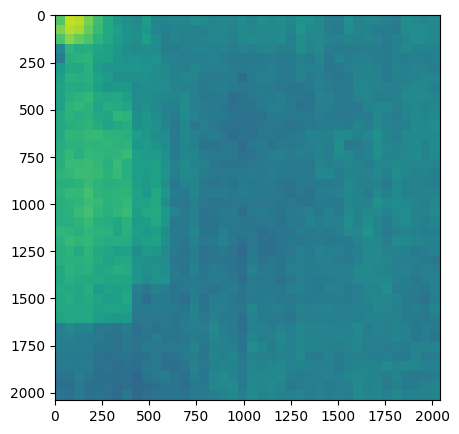

In [ ]:
fig, ax = plt.subplots(figsize=(5, 5))
plt.imshow(
    flat_interp,
    vmin=-10,
    vmax=10,
    interpolation="none",
);

In [ ]:
data = (
    ds["SCI"]
    .sel(observation_id=obs_id, dither=0, filter="J", detector="DET11")
    .compute()
)
flat = flats.sel(filter="J", detector="DET11")
corrected = apply_skyflat(data, flat).compute()

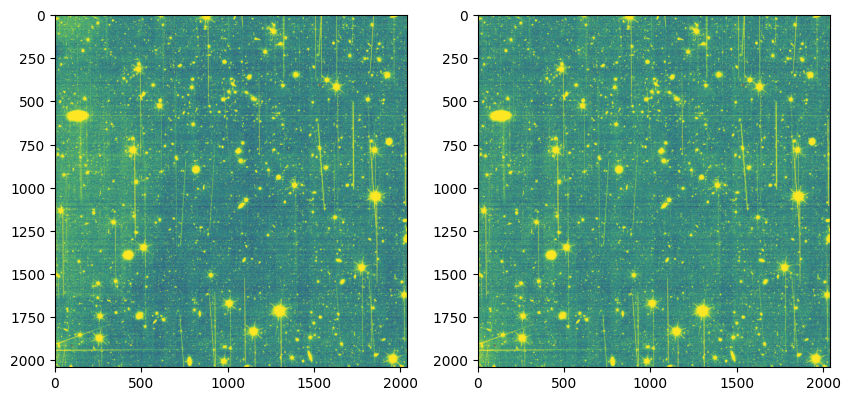

In [ ]:
fig, ax = plt.subplots(1, 2, figsize=(10, 5))
ax[0].imshow(data.to_numpy(), vmin=50, vmax=100)
ax[1].imshow(corrected.to_numpy(), vmin=50, vmax=100);

Check that we can write to FITS, read, interpolate and apply with the same results.

In [ ]:
write_skyflats(obs_id, flats, outpath, wcs=None, flats_err=None)

In [ ]:
flat_from_fits = read_skyflat(
    obs_id, filter="J", detector="DET11", skyflat_path=outpath
)

In [ ]:
flat_interp_from_fits = interpolate_skyflats(flat_from_fits, data)

In [ ]:
assert np.allclose(
    flats_interp.sel(filter="J", detector="DET11").to_numpy(), flat_interp_from_fits
)

In [ ]:
corrected_from_fits = apply_skyflat(data, flat_from_fits)

In [ ]:
assert np.allclose(corrected.to_numpy(), corrected_from_fits)